
AVALIAÇÃO FINAL SVR OTIMIZADO - ÚLTIMOS 60 DIAS
Melhores parâmetros : {'svr__C': 50000, 'svr__epsilon': 100, 'svr__gamma': 0.01}
------------------------------------------------------------
RMSE : 4088.01
MAE  : 2499.68
MAPE : 12.60%
R²   : 0.9374



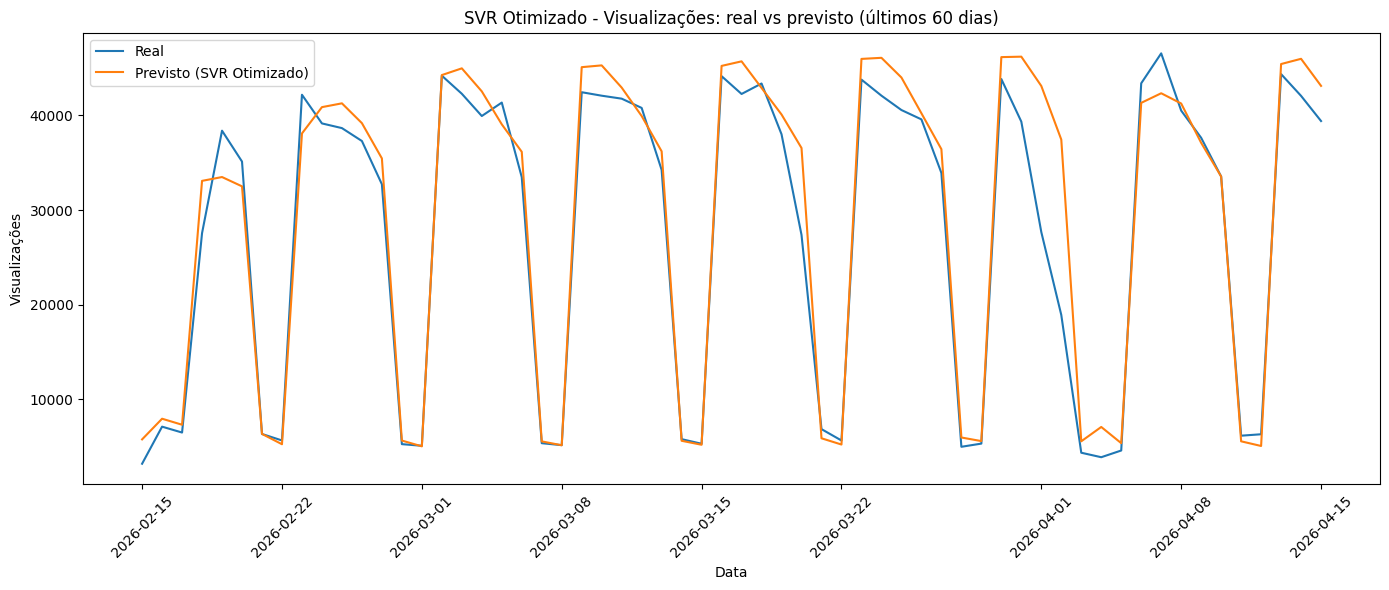

Arquivos salvos localmente com sucesso.


In [1]:
# %% [markdown]
# ## 1. Geração da base específica para o modelo SVR
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. Leitura da base geral tratada
# ============================================================
df = pd.read_csv("../dados/trafego_tratado.csv")
df["Data"] = pd.to_datetime(df["Data"])
df = df.sort_values("Data").reset_index(drop=True)

# %% [markdown]
# ## 2. e 3. Seleção de Variáveis e Criação de Lags / Médias Móveis
df_svr = df.copy()

colunas_svr = [
    "Data", "Visualizações", "dia_semana", "fim_de_semana", "mes",
    "recesso_judiciario", "feriado_nacional_fixo", "carnaval",
    "quarta_cinzas", "sexta_paixao", "corpus_christi",
    "data_especifica_judiciario", "ponto_facultativo_emenda"
]
df_svr = df_svr[colunas_svr].copy()

# Lags da variável-alvo (Evitando vazamento do dia previsto)
df_svr["vis_lag_1"] = df_svr["Visualizações"].shift(1)
df_svr["vis_lag_7"] = df_svr["Visualizações"].shift(7)
df_svr["vis_lag_30"] = df_svr["Visualizações"].shift(30)

# Médias móveis defasadas da variável-alvo
df_svr["vis_mm_7"] = df_svr["Visualizações"].shift(1).rolling(window=7).mean()
df_svr["vis_mm_30"] = df_svr["Visualizações"].shift(1).rolling(window=30).mean()

# %% [markdown]
# ## 4. Remoção de linhas sem histórico suficiente
df_svr = df_svr.dropna().reset_index(drop=True)

# %% [markdown]
# ## 5. Separação temporal entre treino e teste
dias_teste = 60

y = df_svr["Visualizações"]
X = df_svr.drop(columns=["Data", "Visualizações"])

X_train = X.iloc[:-dias_teste].copy()
X_test = X.iloc[-dias_teste:].copy()

y_train = y.iloc[:-dias_teste].copy()
y_test = y.iloc[-dias_teste:].copy()

datas_test = df_svr["Data"].iloc[-dias_teste:].copy()

# %% [markdown]
# ## 6. Avaliação e Ajuste de Hiperparâmetros (GridSearch Otimizado)
def calcular_mape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mascara = y_true != 0
    return np.mean(np.abs((y_true[mascara] - y_pred[mascara]) / y_true[mascara])) * 100

pipeline_svr = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf"))
])

# Grade de parâmetros ajustada para capturar modelos mais robustos
param_grid = {
    "svr__C": [1000, 5000, 10000, 50000],
    "svr__epsilon": [100, 500, 1000, 2000],
    "svr__gamma": ["scale", 0.001, 0.01, 0.1]
}

tscv = TimeSeriesSplit(n_splits=5)

grid_svr = GridSearchCV(
    estimator=pipeline_svr,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1,
    verbose=0 # Silenciado para limpar o console
)

grid_svr.fit(X_train, y_train)
melhor_modelo_svr = grid_svr.best_estimator_

# %% [markdown]
# ## 7. Previsão e Métricas Finais
y_pred_svr_otimizado = melhor_modelo_svr.predict(X_test)

rmse_svr_otimizado = np.sqrt(mean_squared_error(y_test, y_pred_svr_otimizado))
mae_svr_otimizado = mean_absolute_error(y_test, y_pred_svr_otimizado)
mape_svr_otimizado = calcular_mape(y_test, y_pred_svr_otimizado)
r2_svr_otimizado = r2_score(y_test, y_pred_svr_otimizado)

# IMPRESSÃO FORÇADA DAS MÉTRICAS
print("\n" + "=" * 60)
print("AVALIAÇÃO FINAL SVR OTIMIZADO - ÚLTIMOS 60 DIAS")
print("=" * 60)
print(f"Melhores parâmetros : {grid_svr.best_params_}")
print("-" * 60)
print(f"RMSE : {rmse_svr_otimizado:.2f}")
print(f"MAE  : {mae_svr_otimizado:.2f}")
print(f"MAPE : {mape_svr_otimizado:.2f}%")
print(f"R²   : {r2_svr_otimizado:.4f}")
print("=" * 60 + "\n")

# %% [markdown]
# ## 8. Visualização
plt.figure(figsize=(14, 6))
plt.plot(datas_test, y_test.values, label="Real")
plt.plot(datas_test, y_pred_svr_otimizado, label="Previsto (SVR Otimizado)")

plt.title("SVR Otimizado - Visualizações: real vs previsto (últimos 60 dias)")
plt.xlabel("Data")
plt.ylabel("Visualizações")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 9. Salvamento das métricas
metricas_svr = pd.DataFrame({
    "modelo": ["SVR otimizado"],
    "rmse": [rmse_svr_otimizado],
    "mae": [mae_svr_otimizado],
    "mape": [mape_svr_otimizado],
    "r2": [r2_svr_otimizado]
})

# Salvando no diretório atual para garantir que não haja erro de pathing invisível
metricas_svr.to_csv("metricas_svr_otimizado.csv", index=False)

previsao_svr = pd.DataFrame({
    "Data": datas_test.values,
    "real": y_test.values,
    "previsto_svr": y_pred_svr_otimizado
})
previsao_svr.to_csv("previsao_svr_otimizado.csv", index=False)

print("Arquivos salvos localmente com sucesso.")